In [1]:
import numpy as np
xf_train = np.load("processed-imgs/xf_train.npy")
xf_test = np.load("processed-imgs/xf_test.npy")
y_train = np.load("processed-imgs/y_train.npy")
y_test = np.load("processed-imgs/y_test.npy")
xi_train = np.load("processed-imgs/xi_train.npy")
xi_test = np.load("processed-imgs/xi_test.npy")
x_train_scaled = np.load("processed-imgs/xf_train_scaled.npy")
x_test_scaled = np.load("processed-imgs/xf_test_scaled.npy")



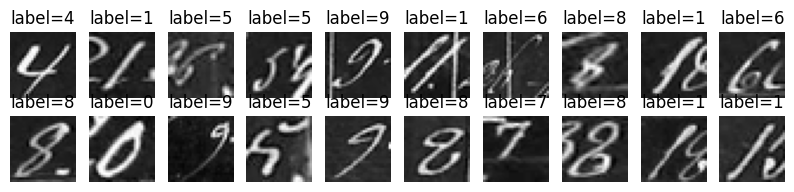

In [3]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import  cross_validate
from time import time
Gnb = GaussianNB()



In [5]:
help(GaussianNB)

Help on class GaussianNB in module sklearn.naive_bayes:

class GaussianNB(_BaseNB)
 |  GaussianNB(*, priors=None, var_smoothing=1e-09)
 |
 |  Gaussian Naive Bayes (GaussianNB).
 |
 |  Can perform online updates to model parameters via :meth:`partial_fit`.
 |  For details on algorithm used to update feature means and variance online,
 |  see `Stanford CS tech report STAN-CS-79-773 by Chan, Golub, and LeVeque
 |  <http://i.stanford.edu/pub/cstr/reports/cs/tr/79/773/CS-TR-79-773.pdf>`_.
 |
 |  Read more in the :ref:`User Guide <gaussian_naive_bayes>`.
 |
 |  Parameters
 |  ----------
 |  priors : array-like of shape (n_classes,), default=None
 |      Prior probabilities of the classes. If specified, the priors are not
 |      adjusted according to the data.
 |
 |  var_smoothing : float, default=1e-9
 |      Portion of the largest variance of all features that is added to
 |      variances for calculation stability.
 |
 |      .. versionadded:: 0.20
 |
 |  Attributes
 |  ----------
 |  cla

In [6]:
start = time()
kf_scores=cross_validate(Gnb, x_train_scaled, y_train, cv=5, scoring='accuracy',return_train_score=True
,verbose=5555)
time_Gnb_kf = time() - start
print(f"KFold Cross-validation train time: {time_Gnb_kf:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores['test_score']}")

[CV] START .....................................................................
[CV] END ..................., score=(train=0.527, test=0.517) total time=   0.2s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.8s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.536, test=0.519) total time=   0.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    1.8s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.537, test=0.504) total time=   0.1s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    2.6s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.534, test=0.502) total time=   0.1s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    3.4s
[CV] START .....................................................................
[CV] END ..................

In [7]:
avg_kf_score_Gnb_train = np.mean(kf_scores['train_score'])
print(f"Average KFold Cross-validation train Accuracy: {avg_kf_score_Gnb_train:.4f}")
std_kf_score_Gnb_train = np.std(kf_scores['train_score'])
print(f"Standard Deviation of KFold Cross-validation train Accuracy: {std_kf_score_Gnb_train:.4f}")

avg_kf_score_Gnb_test = np.mean(kf_scores['test_score'])
print(f"Average KFold Cross-validation test Accuracy: {avg_kf_score_Gnb_test:.4f}")
std_kf_score_Gnb_test = np.std(kf_scores['test_score'])
print(f"Standard Deviation of KFold Cross-validation  test Accuracy: {std_kf_score_Gnb_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.5334
Standard Deviation of KFold Cross-validation train Accuracy: 0.0033
Average KFold Cross-validation test Accuracy: 0.5117
Standard Deviation of KFold Cross-validation  test Accuracy: 0.0074


In [8]:
start = time()
Gnb.fit(x_train_scaled, y_train)
time_Gnb_kf += time() - start

In [47]:
print(Gnb.theta_.shape)
print(Gnb.theta_)
print(Gnb.var_.shape)

(10, 784)
[[-0.10873424 -0.15724216 -0.18909681 ... -0.0890863  -0.08334287
  -0.03701251]
 [ 0.11082921  0.09888669  0.08977886 ...  0.13790466  0.1484465
   0.18046269]
 [-0.08918098 -0.1068493  -0.07873875 ...  0.03494169  0.06544407
   0.08239017]
 ...
 [ 0.03183566  0.05376239  0.0326913  ...  0.07715205  0.03674744
   0.01608483]
 [ 0.10643377  0.10734214  0.10466184 ... -0.00286343 -0.00948374
  -0.01473365]
 [ 0.03766879  0.05117052  0.05396509 ...  0.10971097  0.13107026
   0.13267887]]
(10, 784)


In [9]:
y_test_pred = Gnb.predict(x_test_scaled)
y_train_pred = Gnb.predict(x_train_scaled)
y_test_pred

array([7, 7, 3, ..., 2, 1, 9], dtype=int64)

In [11]:
Gnb.predict_proba(x_test_scaled)[8].shape

(10,)

In [10]:
help(Gnb.predict_proba)

Help on method predict_proba in module sklearn.naive_bayes:

predict_proba(X) method of sklearn.naive_bayes.GaussianNB instance
    Return probability estimates for the test vector X.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        The input samples.

    Returns
    -------
    C : array-like of shape (n_samples, n_classes)
        Returns the probability of the samples for each class in
        the model. The columns correspond to the classes in sorted
        order, as they appear in the attribute :term:`classes_`.



In [12]:
print(f"GaussianNB Multinomial Train Accuracy: {Gnb.score(x_train_scaled, y_train):.4f}")

print(f"GaussianNB Multinomial Test Accuracy: {Gnb.score(x_test_scaled, y_test):.4f}")

GaussianNB Multinomial Train Accuracy: 0.5305
GaussianNB Multinomial Test Accuracy: 0.5140


In [13]:
from cmetrics import *
accuracy_Gnb = acc(y_test, y_test_pred)
print(f"GaussianNB Multi Accuracy: {accuracy_Gnb:.4f}%")
prec_Gnb = precision(y_test, y_test_pred)
print(f"GaussianNB Multi Precision: {prec_Gnb:.4f}%")
rec_Gnb = recall(y_test, y_test_pred)
print(f"GaussianNB Multi Recall: {rec_Gnb:.4f}%")
f1_score_Gnb = f1(y_test, y_test_pred)
print(f"GaussianNB Multi F1 Score: {f1_score_Gnb:.4f}%")

GaussianNB Multi Accuracy: 51.4000%
GaussianNB Multi Precision: 54.2644%
GaussianNB Multi Recall: 51.4000%
GaussianNB Multi F1 Score: 51.6483%


In [14]:
import json

metrics = {
    "accuracy": accuracy_Gnb,
    "precision": prec_Gnb,
    "recall": rec_Gnb,
    "f1_score": f1_score_Gnb,
    "train_time": time_Gnb_kf
}

with open("experiments/Gnb.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.57      0.60      0.59       200
           1       0.32      0.67      0.44       200
           2       0.55      0.36      0.44       200
           3       0.50      0.61      0.55       200
           4       0.53      0.43      0.48       200
           5       0.63      0.45      0.52       200
           6       0.70      0.58      0.64       200
           7       0.58      0.51      0.54       200
           8       0.46      0.38      0.41       200
           9       0.58      0.56      0.57       200

    accuracy                           0.51      2000
   macro avg       0.54      0.51      0.52      2000
weighted avg       0.54      0.51      0.52      2000



In [16]:
cm=conf_matrix(y_test, y_test_pred)
cm

array([[120,  26,   3,   8,  16,   7,   8,   2,   2,   8],
       [  2, 133,   3,  17,   5,   5,   7,  20,   4,   4],
       [  4,  39,  72,  41,   6,   1,   1,  11,  16,   9],
       [ 12,  24,  13, 122,   7,   2,   0,   2,   6,  12],
       [ 18,  27,   8,   4,  86,   1,   9,   7,  23,  17],
       [ 11,  45,  10,   3,   6,  89,  13,   5,  13,   5],
       [ 13,  35,   3,   2,   3,  16, 116,   4,   7,   1],
       [  5,  34,   6,  11,  10,   3,   1, 102,  13,  15],
       [ 13,  29,   7,  20,  12,  17,  10,   6,  76,  10],
       [ 11,  19,   5,  18,  10,   1,   0,  17,   7, 112]], dtype=int64)

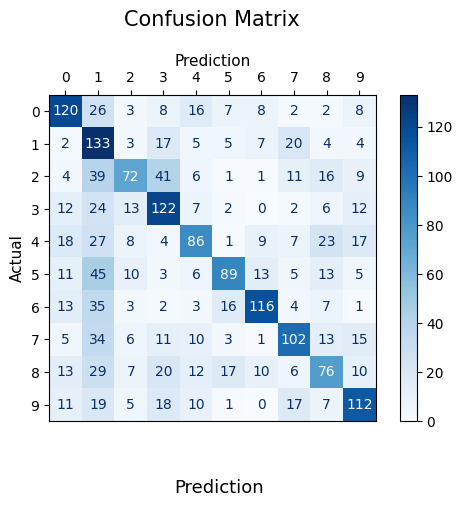

In [17]:
plot_confusion_matrix(cm)